## Example of opening a SASSIE ECCO Icechunk store

#### Python environment

icechunk == 1.1.19

xarray == 2025.6.1

earthaccess == 0.16.0

In [1]:
import icechunk
import xarray as xr
import earthaccess

### 1. Boiler plate function to access the icechunk store needs no modification

In [13]:
def open_readonly_icechunkstore_s3(prefix_store, creds_store, creds_virtual_chunks, 
                           bucket_virtual_chunks = "s3://podaac-ops-cumulus-protected/", 
                           bucket_store = "podaac-ops-cumulus-public"):
    """
    Opens and returns an icechunk store with read-only capabilities.

    Inputs
    ------
    prefix_store: str or path
        Path inside the bucket to the icechunk store.
    creds_virtual_chunks: dict
        Credentials to access the icechunk store (e.g. EDL creds for NASA Earthdata). Expected
        dictionary keys are "accessKeyId", "secretAccessKey", and "sessionToken".
    creds_store: dict
        Credentials to access the science data that the icechunk store points to (e.g. EDL creds 
        for NASA Earthdata). Expected dictionary keys are "accessKeyId", "secretAccessKey",
        and "sessionToken".
    bucket_virtual_chunks: str
        Name of bucket containing the science data that the icechunk store points to. E.g. for
        PO.DAAC data this might be "s3://podaac-ops-cumulus-protected/". Note you need
        the "s3://" prefix.
    bucket_store:
        Name of bucket containing the icechunk store. Note that the "s3://" prefix should not be
        added, e.g. "podaac-ops-cumulus-public".
    """
    
    # 1. Create the raw static credentials object for virtual chunks
    virtualchunk_static_creds = icechunk.s3_static_credentials(
        access_key_id = creds_virtual_chunks["accessKeyId"],
        secret_access_key = creds_virtual_chunks["secretAccessKey"],
        session_token = creds_virtual_chunks["sessionToken"]
    )
    auth_map = icechunk.containers_credentials({
        bucket_virtual_chunks: virtualchunk_static_creds
    })
    
    # 2. Config for the store / metadata repository
    storage = icechunk.s3_storage(
        bucket = bucket_store,
        prefix = prefix_store,
        access_key_id = creds_store['accessKeyId'],
        secret_access_key = creds_store['secretAccessKey'],
        session_token = creds_store['sessionToken']
    )
    
    # 3. Open the repository, passing the compiled auth_map!
    repo = icechunk.Repository.open(
        storage,
        authorize_virtual_chunk_access=auth_map
    )
    
    # 4. Return the store
    session = repo.readonly_session("main")
    return session.store

### 2. Access store and open data with Xarray

In [3]:
# Authenticate with NASA Earthdata and dynamically fetch S3 credentials
earthaccess.login() # Uses your ~/.netrc file or environment variables if configured
ea_creds = earthaccess.get_s3_credentials(daac="PODAAC")

Enter your Earthdata Login username:  deanh808
Enter your Earthdata password:  ········


In [14]:
store = open_readonly_icechunkstore_s3(
    "virtual_collections/SASSIE_ECCO_V1R1/SASSIE_ECCO_SNAPSHOT_V1R1_ALL.icechunk/", 
    ea_creds, ea_creds, 
    bucket_virtual_chunks = "s3://podaac-ops-cumulus-protected", 
    bucket_store = "podaac-ops-cumulus-public"
)

In [15]:
%%time
ds = xr.open_zarr(store, consolidated=False)
ds

/opt/coiled/env/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


CPU times: user 55.2 ms, sys: 11.2 ms, total: 66.5 ms
Wall time: 400 ms


<xarray.Dataset> Size: 124GB
Dimensions:   (time: 85, j: 1080, i: 1800, k: 90, nb: 4, i_g: 1800, j_g: 1080,
               k_l: 90, nv: 2, k_p1: 91, k_u: 90)
Coordinates: (12/22)
    XC        (j, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    XC_bnds   (j, i, nb) float32 31MB dask.array<chunksize=(1080, 1800, 4), meta=np.ndarray>
    YC        (j, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    XU        (j, i_g) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    Zl        (k_l) float32 360B dask.array<chunksize=(90,), meta=np.ndarray>
    Z_bnds    (k, nv) float32 720B dask.array<chunksize=(90, 2), meta=np.ndarray>
    ...        ...
    XV        (j_g, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
  * k         (k) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * j         (j) int32 4kB 0 1 2 3 4 5 6 ... 1073 1074 1075 1076 1077 1078 1079
    YC_bnds   (j, i, nb) float32 31MB dask.array<chunksize=(1080, 1800, 4), meta=np.ndarray>
  * time      (time) datetime64[ns] 680B 2014-02-01 2014-03-01 ... 2021-02-01
  * k_u       (k_u) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
Dimensions without coordinates: nb, nv
Data variables:
    ETAN      (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    PHIBOT    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIarea    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIheff    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SALT      (time, k, j, i) float32 59GB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    THETA     (time, k, j, i) float32 59GB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    SIhsnow   (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIvice    (time, j_g, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIuice    (time, j, i_g) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    sIceLoad  (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
Attributes: (12/45)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    time_coverage_resolution:          PT0S
    geospatial_vertical_max:           0.0
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter

CPU times: user 881 ms, sys: 178 ms, total: 1.06 s
Wall time: 1.16 s


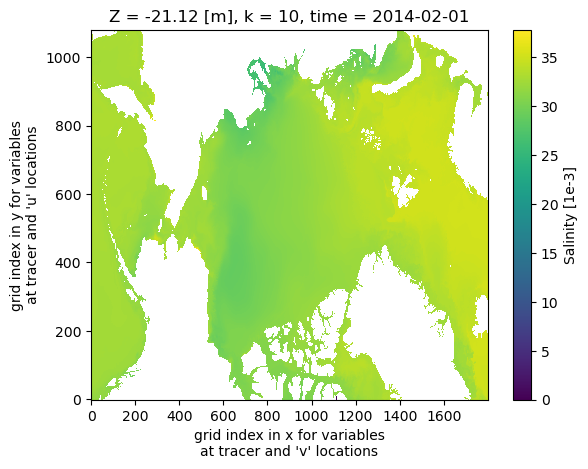

In [16]:
%%time
ds["SALT"].isel(time=0, k=10).plot()

CPU times: user 4.39 s, sys: 661 ms, total: 5.05 s
Wall time: 6.3 s


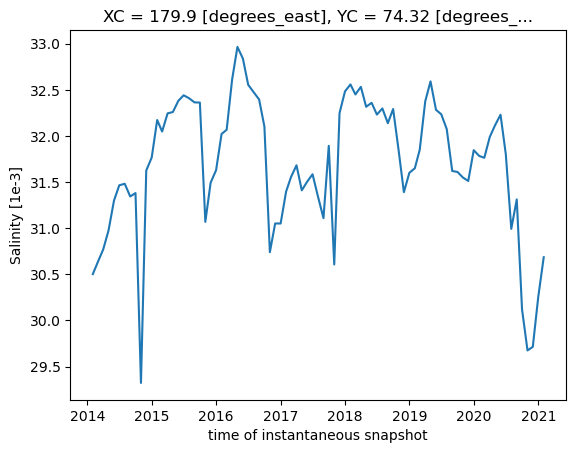

In [17]:
%%time
ds["SALT"].isel(i=600, j=600, k=10).plot()